# Analysis of time spent in sync cluster (In Progress)

Done:  
1. Also include time spent in sync state for transitions which never fall back
2. Plot - Y axis: Number of trasitions; X axis: Timesteps/time
3. Defined algo in notebook
4. Completed and plotted for 200 iterations data


To do:
1. Plot for 1000 iterations data

#### Import libraries


In [14]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc


import statistics
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import glob

#### Create objects for classes


In [15]:
reader=DataRead()
analyse = AnalysisFunc()

#### Import data

In [16]:
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
df_itr.shape

(40000, 200)

#### Analyse how many transitions and time spent it is according to previous algo

In [17]:
l=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [6]:
avg_sync_time=sum(l['sync'])/len(l['sync'])
print(avg_sync_time)

405.78361111111104


In [7]:
statistics.median(l['sync'])

269.26250000000005

In [8]:
l['sync'][0:3]

[109.9, 154.60000000000002, 91.85000000000001]

In [9]:
p=analyse.trans_state_time(analyse.smooth(df_itr[11]),0.05)

In [10]:
p['low_cros']

[491.3, 645.9000000000001]

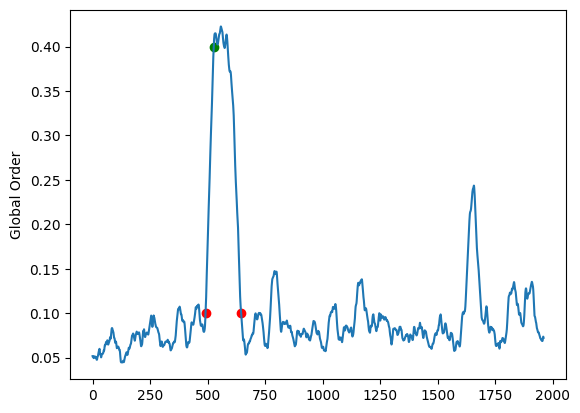

In [11]:
analyse.plot_global_synchrony(df_itr[11],0.05)

In [12]:
n3=analyse.trans_state_time(analyse.smooth(df_itr[3]),0.05)
print(n3['low_cros'])
print(n3['up_cros'])

[612.85]
[649.6500000000001]


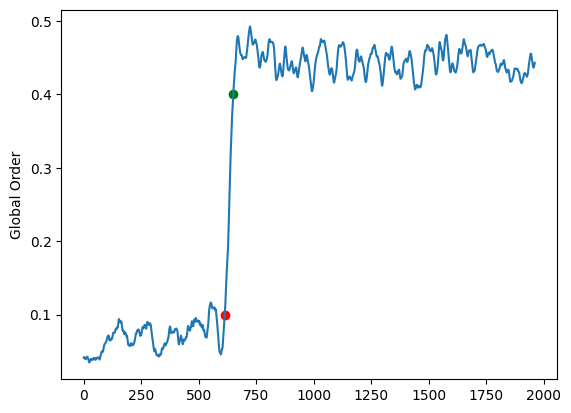

In [13]:
analyse.plot_global_synchrony(df_itr[3],0.05)

#### Let's compute the sync time as discussed

In [30]:
# call compute param to know which iterations have single transitions and which fell back or had multiple transitions

# to store the sync time for every iteration 
sync_time=[]

# call compute_param to get lists of iterations having transitions
param=analyse.compute_param(df_itr,0.05)

# lst1 store iteration numbers which had transitions (single and multiple both)
lst1=param['itr_tran']
# lst2 stores iteration numbers which have fall back or multiple transitions 
lst2=param['itr_st']

# finding only those iterations which have only single transitions
itr_list=set(lst1)-set(lst2)
# print(f'itr_list is {itr_list}')

# iterating over itr_list iterations to find out time spent in sync state
for i in itr_list:
    df_smooth=analyse.smooth(df_itr[i])
    pm=analyse.trans_state_time(df_smooth,0.05)
    st=2000-pm['low_cros'][0]
    sync_time.append(st)

#print(sync_time)
#print(len(sync_time))
print(len(itr_list))
#print(param['sync'])

# merging both time spent for single transition and multiple/fallback transition iterations
time_spent=sync_time+param['sync']
time_spent.sort()

print(time_spent)
# print(len(time_spent))
print(len(param['itr_tran']))

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
78
[91.85000000000001, 99.55000000000001, 109.9, 127.35, 127.55000000000001, 129.54999999999995, 141.65, 154.60000000000002, 170.55, 175.05, 189.15, 199.60000000000002, 212.9, 236.70000000000002, 255.86666666666667, 263.27500000000003, 275.25,

#### Algo to plot time spent in sync state 

In [23]:
# make time comparision list

time = list(range(50,2000,50))
# make list of zeros to increment accordingly

counts = [0]*len(time)

# comparing with time spent llist

for sync in time_spent:
    for i, t in enumerate(time):
        ind = 0
        if sync < t:
            while ind<i:
                counts[ind]+=1
                ind+=1
            break

print(counts)
            
            


[108, 106, 101, 96, 94, 91, 91, 88, 87, 87, 86, 83, 81, 80, 76, 74, 73, 71, 71, 71, 70, 69, 65, 63, 58, 54, 50, 45, 40, 37, 30, 23, 18, 13, 7, 1, 0, 0, 0]


Text(0, 0.5, 'Number of Iterations')

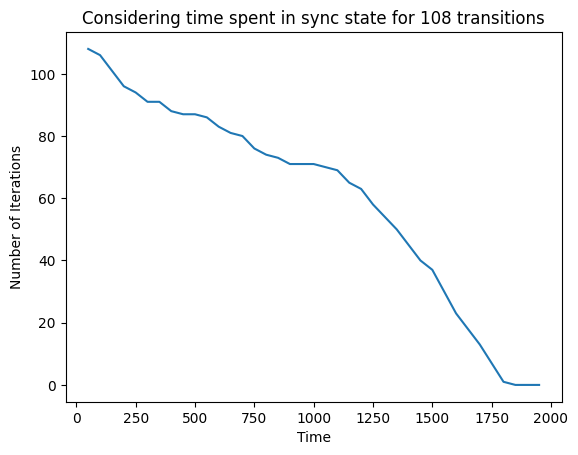

In [31]:
plt.plot(time,counts)
plt.title('Considering time spent in sync state for 108 transitions')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')

In [25]:
print(time)

[50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900, 1950]


In [24]:
print(time_spent)

[91.85000000000001, 99.55000000000001, 109.9, 127.35, 127.55000000000001, 129.54999999999995, 141.65, 154.60000000000002, 170.55, 175.05, 189.15, 199.60000000000002, 212.9, 236.70000000000002, 255.86666666666667, 263.27500000000003, 275.25, 356.20000000000005, 370.18333333333334, 384.5833333333333, 426.39999999999986, 541.0999999999999, 553.3000000000001, 556.0, 572.15, 613.5, 637.675, 667.75, 703.7, 722.0250000000001, 725.0999999999999, 733.3999999999999, 750.3999999999999, 787.3999999999999, 846.35, 891.7, 894.8, 1026.4, 1084.8, 1102.3, 1108.4499999999998, 1121.8, 1127.15, 1172.55, 1186.5, 1225.4, 1225.9499999999998, 1237.85, 1239.15, 1243.65, 1257.0, 1266.75, 1274.25, 1281.1999999999998, 1319.25, 1320.65, 1328.0, 1339.9, 1352.85, 1358.35, 1358.85, 1387.15, 1391.25, 1420.5, 1439.1, 1439.1999999999998, 1440.3, 1444.55, 1453.5, 1482.15, 1493.1, 1500.9, 1506.6, 1537.2, 1538.65, 1538.9, 1539.3, 1549.2, 1553.8, 1569.4, 1585.3, 1585.4, 1592.15, 1596.4, 1599.35, 1601.55, 1602.7, 1609.3, 161

# Delete above cells after above is defined as a function

In [18]:
def compute_time_spent(df,sim_time):
    '''
    '''
    # call compute param to know which iterations have single transitions and which fell back or had multiple transitions
    
    # to store the sync time for every iteration 
    sync_time=[]
    
    # call compute_param to get lists of iterations having transitions
    param=analyse.compute_param(df,0.05)
    
    # lst1 store iteration numbers which had transitions (single and multiple both)
    lst1=param['itr_tran']
    # lst2 stores iteration numbers which have fall back or multiple transitions 
    lst2=param['itr_st']
    
    # finding only those iterations which have only single transitions
    itr_list=set(lst1)-set(lst2)
    # print(f'itr_list is {itr_list}')
    
    # iterating over itr_list iterations to find out time spent in sync state
    for i in itr_list:
        df_smooth=analyse.smooth(df_itr[i])
        pm=analyse.trans_state_time(df_smooth,0.05)
        st=sim_time-pm['low_cros'][0]
        sync_time.append(st)
    
    #print(sync_time)
    #print(len(sync_time))
    print(len(itr_list))
    #print(param['sync'])
    
    # merging both time spent for single transition and multiple/fallback transition iterations
    time_spent=sync_time+param['sync']
    time_spent.sort()
    
    print(time_spent)
    # print(len(time_spent))
    print(len(param['itr_tran']))


    # make time comparision list

    time = list(range(50,sim_time,50))
    # make list of zeros to increment accordingly
    
    counts = [0]*len(time)
    
    # comparing with time spent llist
    
    for sync in time_spent:
        for i, t in enumerate(time):
            ind = 0
            if sync < t:
                while ind<i:
                    counts[ind]+=1
                    ind+=1
                break
    
    print(counts)

    keys=['counts','time','time_spent']
    values=[counts,time,time_spent]
    sync_dict = dict(zip(keys,values))
    return sync_dict

    
    

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
78
[91.85000000000001, 99.55000000000001, 109.9, 127.35, 127.55000000000001, 129.54999999999995, 141.65, 154.60000000000002, 170.55, 175.05, 189.15, 199.60000000000002, 212.9, 236.70000000000002, 255.86666666666667, 263.27500000000003, 275.25,

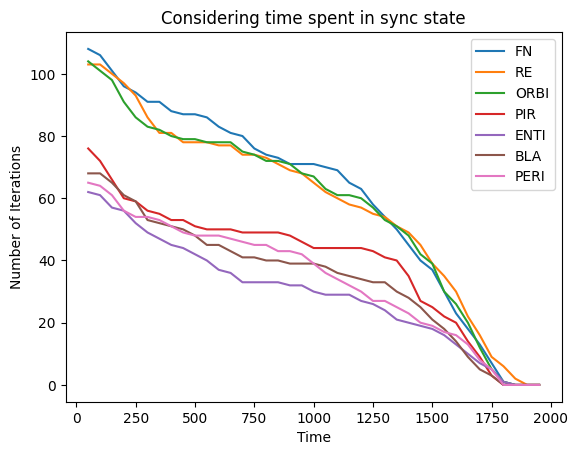

In [19]:
names = ['FN', 'RE', 'ORBI', 'PIR', 'ENTI', 'BLA', 'PERI']  # List of names to iterate through

for name in names:
    file_path = f'raw/{name}/itr_200.bz2'
    df_itr = reader.data_read_bz2(file_path)
    
    plot_data=compute_time_spent(df_itr,2000)
    plt.plot(plot_data['time'],plot_data['counts'],label=name)
    
plt.title('Considering time spent in sync state')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')
plt.legend()

#### Plot of 1000 iteration data

../../data/processed
['../../data/processed/itr_bla.bz2', '../../data/processed/itr_fn.bz2', '../../data/processed/itr_pir.bz2', '../../data/processed/itr_re.bz2', '../../data/processed/itr_orbi.bz2', '../../data/processed/itr_enti.bz2', '../../data/processed/itr_peri.bz2']
Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67, 69, 73, 78, 79, 85, 92, 93, 98, 104, 106, 109, 110, 112, 115, 117, 121, 125, 130, 134, 135, 141, 142, 145, 148, 149, 151, 156, 158, 159, 162, 166, 168, 172, 173, 177, 180, 181, 182, 184, 187, 191, 192, 193, 197, 198, 210, 211, 214, 218, 223, 224, 226, 227, 228, 229, 232, 237, 239, 245, 246, 247, 250, 258, 262, 264, 274, 281, 283, 295, 296, 297, 298, 303, 305, 314, 320, 322, 326, 328, 329, 333, 334, 336, 342, 343, 345, 347, 348, 350, 351, 356, 359, 360, 365, 368, 370, 371, 375, 378, 382, 384, 385, 392, 395, 396, 397, 3

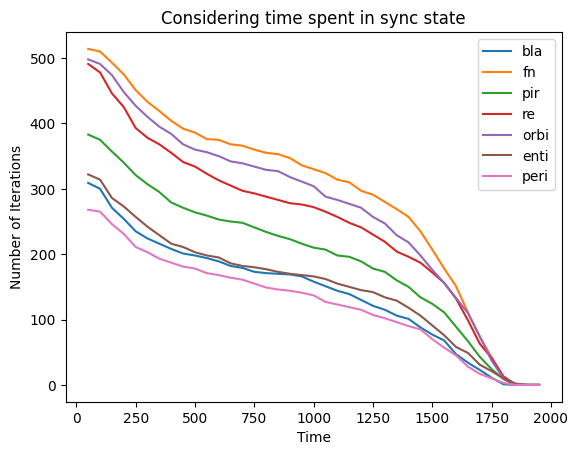

In [24]:
data_folder = Path(f'../../data/processed')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_*.bz2"))
print(files)

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]
    
    df_itr = pd.read_pickle(f,compression='bz2')
    
    plot_data=compute_time_spent(df_itr,2000)
    plt.plot(plot_data['time'],plot_data['counts'],label=name_suffix)
    
plt.title('Considering time spent in sync state')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')
plt.legend()